# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [1]:
##% title Imports
import os
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV, RidgeCV, LassoCV, Lasso
from scipy import stats

from popy.io_tools import *
from popy.behavior_data_tools import *
from popy.neural_data_tools import time_normalize_session, scale_neural_data, remove_low_fr_neurons, remove_trunctuated_neurons
from popy.decoding.decoder_tools import *
from popy.plotting.plotting_tools import *
#from popy.plotting.plot_behavior import show_target_selection 
import popy.config as cfg
from popy.plotting.plot_cortical_grid import plot_on_cortical_grid

PATH = cfg.PROJECT_PATH_LOCAL


In [2]:
##% data loading
def load_data_custom(monkey, session, area=None, n_extra_trials=(0, 0)):
    # 1. Behavior data

    # Load behavior data
    behav = load_behavior(monkey, session)
    behav = drop_time_fields(behav)

    # add behav vars to decode
    behav = add_stay_value(behav, reset_on_switch=True)  # add shift value for its decoding
    behav = add_switch_info(behav)  # add switch information for its decoding
    behav = add_history_of_feedback(behav, num_trials=1, one_column=False)

    # 2. Neural data

    # Load neural data
    neural_data = load_neural_data(monkey, session, hz=1000)

    if area is not None:
        # Filter neural data by area
        neural_data = neural_data.sel(unit=neural_data.unit.str.contains(area))

    # remove some units
    neural_data = remove_low_fr_neurons(neural_data, 1, print_usr_msg=True)
    neural_data = remove_trunctuated_neurons(neural_data, mode='remove', delay_limit=10, print_usr_msg=True)

    # process neural data
    neural_data = add_firing_rates(neural_data, drop_spike_trains=True, method='gauss', std=.05)
    neural_data = downsample_time(neural_data, 100)
    neural_data = scale_neural_data(neural_data)
    neural_data = time_normalize_session(neural_data)

    # 3. build neural dataset and merge with behavior
    neural_dataset = build_trial_dataset(neural_data, mode='full_trial', n_extra_trials=(0, 0))
    neural_dataset = merge_behavior(neural_dataset, behav)

    return neural_dataset

In [9]:
# @title Helper Functions

def project_across_targets(neural_dataset):

    target_vector = neural_dataset['target'].values

    # write back to xarray, preserve the trial and time dimensions and corresponding coordinates
    time_coords = {name: coord for name, coord in neural_dataset.coords.items() if 'time' in coord.dims}
    trial_coords = {name: coord for name, coord in neural_dataset.coords.items() if 'trial_id' in coord.dims}

    # create train and test splits
    clf = LinearRegression()

    projections = np.empty((3, len(neural_dataset.trial_id), len(neural_dataset.time)))
    #scores = np.empty((2, len(neural_dataset.time)))
    for t_id, t in enumerate(neural_dataset.time):
        for fold, target_temp in enumerate(np.unique(target_vector)):
            # get the firing rates for the current time point
            X_train = neural_dataset.firing_rates.sel(trial_id=neural_dataset.target == target_temp, time=t).values
            #X_test = ...
            y_train = neural_dataset.sel(trial_id=neural_dataset.target == target_temp)['stay_value'].values

            # fit the model
            clf.fit(X_train, y_train)

            # save model accuracy on same and alternate trials
            '''
            #X_test = data_test.firing_rates.sel(time=t).values
            #y_test = data_test['stay_value'].values
            pred_same = clf.predict(X_train)
            pred_alter = clf.predict(X_test)
            pearson_r_same, p_same = stats.pearsonr(pred_same, y_train)
            pearson_r_alter, p_alter = stats.pearsonr(pred_alter, y_test)
            scores[:, t_id] = np.array([pearson_r_same, pearson_r_alter])
            
            print(f"Fold {target_temp} -> same: pearson r: {pearson_r_same:.2f}")
            print(f"Fold {target_temp} -> alter: pearson r: {pearson_r_alter:.2f}")
            '''

            # project the dataset (at this point) to this subspace
            weights = clf.coef_.reshape(-1, 1)  # reshape to ensure correct dimensions
            neural_dataset_time = neural_dataset.sel(time=t).firing_rates.data
            data_projected = np.dot(neural_dataset_time, weights)

            projections[fold, :, t_id] = data_projected.squeeze()

    # Create a DataArray with the projected data
    data_projected_da = xr.DataArray(projections, dims=('subspace', 'trial_id', 'time'),
                                      coords={'subspace': [f'target_{int(temp)}' for temp in np.unique(target_vector)],
                                              'trial_id': neural_dataset.trial_id.values,
                                              'time': neural_dataset.time.values})
    # Add the original coordinates
    for name, coord in time_coords.items():
        data_projected_da = data_projected_da.assign_coords({name: coord})
    for name, coord in trial_coords.items():
        data_projected_da = data_projected_da.assign_coords({name: coord})

    return data_projected_da

def extract_neural_data(neural_values, data_projected):
    results = []

    for trial_id in np.unique(data_projected.trial_id.values):
        neural_values_curr = neural_values.sel(trial_id=trial_id)
        if trial_id + 1 not in neural_values.trial_id.values:
            continue
        neural_values_p1 = neural_values.sel(trial_id=trial_id + 1)

        target_curr = neural_values_curr.target.values
        target_p1 = neural_values_p1.target.values
        if target_curr != target_p1:
            continue
        fb = int(neural_values_curr.feedback.values)

        value_same = neural_values_curr.sel(subspace=f'target_{str(int(target_curr))}').data

        df_temp = {'monkey': monkey, 'session': session, 'trial_id': trial_id, 
                    'target': target_curr, 'feedback': fb}

        for subspace in neural_values_curr.subspace.values:
            df_temp_subspace = df_temp.copy()

            if subspace == f'target_{str(int(target_curr))}':
                df_temp_subspace['type'] = 'within'
            else:
                df_temp_subspace['type'] = 'alter'

            V_t = neural_values_curr.sel(subspace=subspace).data
            V_t_p1 = neural_values_p1.sel(subspace=subspace).data
            dV = - V_t + V_t_p1

            df_temp_subspace[f'V_neural'] = float(V_t)
            df_temp_subspace[f'V_neural_p1'] = float(V_t_p1)
            df_temp_subspace[f'dV_neural'] = dV

            df_temp_subspace[f'V_behav'] = neural_values_curr.stay_value.values
            df_temp_subspace[f'V_behav_p1'] = neural_values_p1.stay_value.values
            df_temp_subspace[f'dV_behav'] = df_temp_subspace[f'V_behav'] - df_temp_subspace[f'V_behav_p1']

            results.append(df_temp_subspace)

    # convert to df
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by=['monkey', 'session', 'trial_id'])
    return results_df


---
# Get data

In [4]:
monkey, session, area = 'ka', '050820', 'MCC'
time_of_interest = [2, 3.5]

neural_dataset = load_data_custom(monkey, session, area=area, n_extra_trials=(0, 0))

neural_dataset

Removed 5/14 units with mean firing rate lower than 1 Hz.
removed units: ['MCC_02_02' 'MCC_14_02' 'MCC_14_03' 'MCC_16_01' 'MCC_16_04']
Removed 8/9 units with trunctuated recordings, delay limit: 10 s.
 Invalid units: {'MCC_16_02', 'MCC_15_01', 'MCC_16_03', 'MCC_02_01', 'MCC_08_02', 'MCC_07_01', 'MCC_08_01', 'MCC_14_01'}


<xarray.Dataset>
Dimensions:           (unit: 1, trial_id: 427, time: 750)
Coordinates: (12/20)
  * unit              (unit) object 'MCC_04_01'
    unit_id_original  (unit) int64 7
    channel           (unit) int64 4
    monkey            (unit) object 'ka'
    session           (unit) object '050820'
    area              (unit) object 'MCC'
    ...                ...
    stay_value        (trial_id) float64 0.1183 0.06983 ... 0.09277 0.4795
    V0                (trial_id) float64 0.1183 0.1183 0.1183 ... 0.1183 0.1183
    stay_proba        (trial_id) float64 0.5 0.3739 0.3058 ... 0.4326 0.979
    switch            (trial_id) float64 nan 0.0 1.0 1.0 1.0 ... 0.0 0.0 1.0 0.0
    R_1               (trial_id) float64 nan 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 1.0
    T_1               (trial_id) float64 nan 3.0 3.0 1.0 3.0 ... 3.0 3.0 3.0 2.0
Data variables:
    firing_rates      (trial_id, unit, time) float64 -0.02063 -0.7232 ... -0.747
Attributes:
    bin_size:  0.01

---
# Section 1: Projection to value subspace

## Define the value subspace

In [10]:
# project the neural data across targets - from high dimensional space to 3 dimensional space
data_projected = project_across_targets(neural_dataset)
data_projected

<xarray.DataArray (subspace: 3, trial_id: 427, time: 750)>
array([[[ 0.00148651,  0.05063923,  0.05258489, ...,  0.00551018,
          0.00447098,  0.00278412],
        [ 0.00526809, -0.00286919, -0.0110575 , ..., -0.00666834,
         -0.00903   , -0.01116249],
        [-0.07881746, -0.07677371, -0.07736417, ...,  0.00548908,
          0.00581344,  0.00554045],
        ...,
        [ 0.05351552,  0.05195887,  0.05218896, ..., -0.02175645,
         -0.02064847, -0.01881183],
        [-0.10144493, -0.09278084, -0.08744166, ..., -0.01984142,
         -0.02202115, -0.02398151],
        [-0.15717521, -0.15231214, -0.15269359, ...,  0.00742285,
          0.00780262,  0.00824534]],

       [[-0.00040826, -0.01410812, -0.01424462, ...,  0.01002773,
          0.0083332 ,  0.004999  ],
        [-0.00144684,  0.00079936,  0.00299535, ..., -0.01213542,
         -0.01683047, -0.02004273],
        [ 0.02164667,  0.0213892 ,  0.02095703, ...,  0.00998935,
          0.01083533,  0.00994811],
...
        [-0.01469766, -0.01447577, -0.01413737, ..., -0.03959363,
         -0.03848545, -0.03377745],
        [ 0.02786114,  0.0258488 ,  0.0236869 , ..., -0.03610855,
         -0.04104391, -0.04305983],
        [ 0.04316708,  0.04243426,  0.04136287, ...,  0.01350852,
          0.01454283,  0.01480485]],

       [[ 0.00052428,  0.01746187,  0.01828213, ...,  0.00717442,
          0.00602672,  0.00369394],
        [ 0.00185801, -0.00098938, -0.00384435, ..., -0.00868238,
         -0.0121721 , -0.01481029],
        [-0.0277983 , -0.02647379, -0.02689712, ...,  0.00714695,
          0.0078363 ,  0.00735101],
        ...,
        [ 0.0188745 ,  0.01791691,  0.01814448, ..., -0.02832756,
         -0.02783337, -0.02495936],
        [-0.03577882, -0.03199351, -0.03040075, ..., -0.02583413,
         -0.02968369, -0.03181844],
        [-0.05543445, -0.05252161, -0.05308682, ...,  0.00966477,
          0.01051763,  0.01093983]]])
Coordinates: (12/14)
  * subspace     (subspace) <U8 'target_1' 'target_2' 'target_3'
  * time         (time) float64 0.0 0.01 0.02 0.03 0.04 ... 7.46 7.47 7.48 7.49
    epoch        (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 5.0 5.0 5.0 5.0 5.0
  * trial_id     (trial_id) int64 0 1 2 3 4 5 6 ... 421 422 423 424 425 426 427
    block_id     (trial_id) int64 0 0 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9 9 9
    best_target  (trial_id) int64 2 2 2 2 2 2 2 2 2 2 2 ... 1 1 1 1 1 1 1 1 1 1
    ...           ...
    stay_value   (trial_id) float64 0.1183 0.06983 0.04122 ... 0.09277 0.4795
    V0           (trial_id) float64 0.1183 0.1183 0.1183 ... 0.1183 0.1183
    stay_proba   (trial_id) float64 0.5 0.3739 0.3058 ... 0.6019 0.4326 0.979
    switch       (trial_id) float64 nan 0.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 1.0 0.0
    R_1          (trial_id) float64 nan 0.0 0.0 0.0 0.0 ... 1.0 0.0 0.0 0.0 1.0
    T_1          (trial_id) float64 nan 3.0 3.0 1.0 3.0 ... 3.0 3.0 3.0 3.0 2.0

In [6]:
# Extract 'neural values' for the specified time range by averaging across time points
neural_values = data_projected.sel(time=slice(*time_of_interest)).mean(dim='time')
neural_values

<xarray.DataArray (subspace: 3, trial_id: 427)>
array([[-5.61542042e-03,  9.37027060e-03, -2.00711814e-02, ...,
        -8.46443025e-05, -1.90618128e-02, -6.59801262e-04],
       [ 4.16714058e-04,  5.27714127e-04, -1.23103203e-02, ...,
        -3.22806824e-02, -1.86103664e-02,  2.78642148e-03],
       [-5.62042883e-03,  2.57151141e-03, -9.87651058e-03, ...,
        -5.39998628e-03, -1.20374558e-02,  7.28091578e-03]])
Coordinates:
  * subspace     (subspace) <U8 'target_1' 'target_2' 'target_3'
  * trial_id     (trial_id) int64 0 1 2 3 4 5 6 ... 421 422 423 424 425 426 427
    block_id     (trial_id) int64 0 0 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9 9 9
    best_target  (trial_id) int64 2 2 2 2 2 2 2 2 2 2 2 ... 1 1 1 1 1 1 1 1 1 1
    target       (trial_id) float64 3.0 3.0 1.0 3.0 1.0 ... 3.0 3.0 3.0 2.0 2.0
    feedback     (trial_id) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 1.0 1.0
    stay_value   (trial_id) float64 0.1183 0.06983 0.04122 ... 0.09277 0.4795
    V0           (trial_id) float64 0.1183 0.1183 0.1183 ... 0.1183 0.1183
    stay_proba   (trial_id) float64 0.5 0.3739 0.3058 ... 0.6019 0.4326 0.979
    switch       (trial_id) float64 nan 0.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 1.0 0.0
    R_1          (trial_id) float64 nan 0.0 0.0 0.0 0.0 ... 1.0 0.0 0.0 0.0 1.0
    T_1          (trial_id) float64 nan 3.0 3.0 1.0 3.0 ... 3.0 3.0 3.0 3.0 2.0

In [7]:
# Extract neural values and their change
results_df = extract_neural_data(neural_values, data_projected)
results_df

,monkey,session,trial_id,target,feedback,type,V_neural,V_neural_p1,dV_neural,V_behav,V_behav_p1,dV_behav
0,ka,050820,0,3.0,0,alter,-0.005615,0.009370,0.014986,0.11827469139505799,0.06982541018249958,0.048449
1,ka,050820,0,3.0,0,alter,0.000417,0.000528,0.000111,0.11827469139505799,0.06982541018249958,0.048449
2,ka,050820,0,3.0,0,within,-0.005620,0.002572,0.008192,0.11827469139505799,0.06982541018249958,0.048449
3,ka,050820,5,2.0,1,alter,0.009391,0.011590,0.002199,0.06982541018249958,0.4794589559655903,-0.409634
4,ka,050820,5,2.0,1,within,-0.000761,0.013514,0.014275,0.06982541018249958,0.4794589559655903,-0.409634
...,...,...,...,...,...,...,...,...,...,...,...,...
1156,ka,050820,424,3.0,0,alter,-0.004730,-0.032281,-0.027551,0.2661703322364448,0.15713803526016662,0.109032
1157,ka,050820,424,3.0,0,within,-0.001409,-0.005400,-0.003991,0.2661703322364448,0.15713803526016662,0.109032
1158,ka,050820,426,2.0,1,alter,-0.019062,-0.000660,0.018402,0.09276902469915622,0.4794589559655903,-0.386690
1159,ka,050820,426,2.0,1,within,-0.018610,0.002786,0.021397,0.09276902469915622,0.4794589559655903,-0.386690


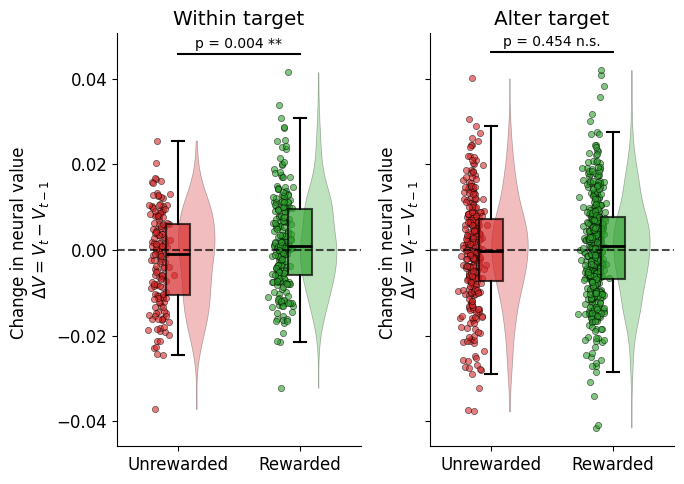

In [16]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# fontsize = 8
plt.rcParams.update({'font.size': 12})

# Create the figure
fig, axs = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

def create_r_style_plot(ax, data, x_col, y_col, palette, title):
    """Create R-style plot with violin, box, and jittered points"""
    
    # Get unique categories
    # sort by x_col
    data = data.copy().sort_values(by=x_col)
    categories = data[x_col].unique()
    x_positions = np.arange(len(categories))
    
    # Create violin plots (distributions) - slightly offset to the right
    violin_parts = ax.violinplot([data.loc[data[x_col] == cat, y_col].values for cat in categories], 
                                positions=x_positions + 0.15, widths=0.3, showmeans=False, 
                                showmedians=False, showextrema=False)
    
    # Color the violin plots
    colors = [palette[str(cat)] for cat in categories]
    for pc, color in zip(violin_parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.3)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)
    
    # Create boxplots - centered
    box_data = [data.loc[data[x_col] == cat, y_col].values for cat in categories]
    bp = ax.boxplot(box_data, positions=x_positions, widths=0.2, patch_artist=True,
                   boxprops=dict(alpha=0.7, linewidth=1.5),
                   showfliers=False,
                   medianprops=dict(color='black', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='black', markersize=3, alpha=0.5))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Add jittered points - slightly offset to the left
    for i, cat in enumerate(categories):
        y_data = data.loc[data[x_col] == cat, y_col].values
        x_jitter = np.random.normal(x_positions[i] - 0.15, 0.04, size=len(y_data))
        ax.scatter(x_jitter, y_data, alpha=0.6, s=20, 
                  color=colors[i], edgecolor='black', linewidth=0.5)
    
    # Perform t-test and add significance
    if len(categories) == 2:
        group1_data = data.loc[data[x_col] == categories[0], y_col]
        group2_data = data.loc[data[x_col] == categories[1], y_col]
        #_, p_value = stats.ttest_ind(group1_data, group2_data)
        _, p_value = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

        
        # Position for significance bar
        y_max = data[y_col].max()
        y_pos = y_max + 0.1 * abs(y_max)
        
        # Add significance annotation
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'n.s.'
        
        # Add the bar and text for p-value
        ax.plot([0, 1], [y_pos, y_pos], '-k', lw=1.5)
        ax.text(0.5, y_pos + 0.02 * abs(y_max), f'p = {p_value:.3f} {significance}', 
                ha='center', va='bottom', fontsize=10)
    
    # Formatting
    ax.axhline(0, linestyle='--', alpha=0.7, color='black')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Unrewarded', 'Rewarded'])
    ax.set_ylabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$')
    ax.set_xlabel('')
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return ax

# Create the plots
palette = {'0': 'tab:red', '1': 'tab:green'}

# Within target plot
create_r_style_plot(axs[0], 
                   results_df.loc[results_df['type'] == 'within'], 
                   'feedback', 'dV_neural', palette, 'Within target')

# Alter target plot
create_r_style_plot(axs[1], 
                   results_df.loc[results_df['type'] == 'alter'], 
                   'feedback', 'dV_neural', palette, 'Alter target')

plt.tight_layout()

# save svg
#plt.savefig('figs/dV_neural_behav_rstyle.svg', format='svg', bbox_inches='tight')